# BENCHMARK 0. TPeanuts vs Legacy Peanuts Precision 
---

This notebook benchmarks how accurately `tpeanuts` reproduces the legacy `peanuts` implementation. The comparison is both numerical, through relative-error diagnostics printed for representative parameter combinations, and visual, through energy spectra and oscillation-probability plots.


## 1. Libraries

This section imports the numerical stack, configures plotting, and exposes both the torch-based `tpeanuts` modules and the legacy NumPy/Numba `peanuts` modules.


In [1]:
from __future__ import annotations

import math
import os
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from tpeanuts.util.notebooks import find_repo_root, save_and_show, save_figure, show_figure
from tpeanuts.util.math import relative_error
from tpeanuts.util.notebooks import print_comparison, print_error_table
from tpeanuts.util.type import to_numpy
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

# The modern package is imported as tpeanuts from the parent directory, while
# legacy peanuts is imported from the repository root.
plt.rcParams.update({
    "figure.figsize": (8.0, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

torch.set_printoptions(precision=10, sci_mode=True, linewidth=160)
np.set_printoptions(precision=10, suppress=False, linewidth=160)

from tpeanuts.core.pmns import PMNS
from tpeanuts.core.probabilities import apply_probability_matrix_to_flux
from tpeanuts.io.io_earth import load_earth_density_from_csv
from tpeanuts.earth.probabilities import pearth
from tpeanuts.flux_propagation.pipeline_incoherent import propagate_solar_to_detector_incoherent
from tpeanuts.flux_propagation.pipeline_legacypeanuts import (
    _ensure_legacy_default_data_aliases,
    propagate_solar_to_detector_legacypeanuts,
)
from tpeanuts.solar.probabilities import psolar, solar_flux_mass
from tpeanuts.solar.profiles import load_default_solar_profile
from tpeanuts.solar.validation import legacy_modules
from tpeanuts.vacuum.probabilities import pvacuum, vacuum_probability_matrix

_ensure_legacy_default_data_aliases()

from peanuts.earth import Pearth as legacy_pearth
from peanuts.earth import earthdensity as LegacyEarthDensity
from peanuts.pmns import PMNS as LegacyPMNS
from peanuts.vacuum import Pvacuum as legacy_pvacuum

print(f"Torch version   : {torch.__version__}")


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Warning!: Python module pyslha not found, disabling slha reading routines
Torch version   : 2.3.1


## 2. Configuration

The benchmark uses a fixed oscillation setup so every block compares the same physics configuration in both implementations.


### 2.1 Paths

Centralized paths keep data inputs and generated figures explicit. The output directory is inside `OUTPUT_BENCHMARK_ROOT` so notebook results do not mix with test artifacts.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_BENCHMARK_ROOT / "0_tpeanuts_vs_peanuts_precision"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path(PACKAGE_DIR / "data")
LEGACY_DATA_DIR = Path(DATA_DIR / "peanuts")

SHOW_PLOTS = True

print("Legacy Data Dir :", LEGACY_DATA_DIR)
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Legacy Data Dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts
Output root     : V:\output
Output directory: V:\output\benchmark\0_tpeanuts_vs_peanuts_precision


### 2.2 Parameters

The parameters below define the PMNS matrix, mass splittings, energy grids, baselines, solar source, nadir angles, detector depth, and synthetic input spectra used in the comparisons.


In [3]:
DEVICE = torch.device("cpu")
DTYPE = torch.float64
CDTYPE = torch.complex128

THETA12 = 0.59
THETA13 = 0.15
THETA23 = 0.78
DELTA_CP = 1.20
DM21_EV2 = 7.42e-5
DM3L_EV2 = 2.517e-3

pmns = PMNS(THETA12, THETA13, THETA23, DELTA_CP, device=DEVICE, real_dtype=DTYPE)
legacy_pmns = LegacyPMNS(THETA12, THETA13, THETA23, DELTA_CP)

ENERGY_GRID_MEV = torch.logspace(torch.log10(torch.tensor(0.5)), torch.log10(torch.tensor(2.0e4)), 180, dtype=DTYPE, device=DEVICE)
VACUUM_ENERGY_GRID_MEV = torch.logspace(torch.log10(torch.tensor(100.0)), torch.log10(torch.tensor(2.0e4)), 220, dtype=DTYPE, device=DEVICE)
SOLAR_ENERGY_GRID_MEV = torch.linspace(0.5, 15.0, 120, dtype=DTYPE, device=DEVICE)
EARTH_ENERGY_GRID_MEV = torch.logspace(torch.log10(torch.tensor(100.0)), torch.log10(torch.tensor(2.0e4)), 120, dtype=DTYPE, device=DEVICE)

VACUUM_BASELINES_KM = [295.0, 735.0, 1300.0, 12000.0]
EARTH_ETA_VALUES_RAD = [0.35, 0.75, 1.20, 2.40]
DETECTOR_DEPTH_M = 0.0
EARTH_METHOD = "analytical"  # "analytical" or "numerical" 
EARTH_NUMERICAL_STEPS = 240
EARTH_ODE_METHOD = "midpoint"
SOLAR_SOURCE = "8B"
DETECTOR_LATITUDE_RAD = 0.7200
EXPOSURE_NS = 41

FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
FLAVOUR_NAMES = ["nue", "numu", "nutau"]
FLAVOUR_STATES = {
    "nue": torch.tensor([1.0, 0.0, 0.0], dtype=CDTYPE, device=DEVICE),
    "numu": torch.tensor([0.0, 1.0, 0.0], dtype=CDTYPE, device=DEVICE),
    "nutau": torch.tensor([0.0, 0.0, 1.0], dtype=CDTYPE, device=DEVICE),
}
MASS_WEIGHTS = torch.tensor([0.20, 0.30, 0.50], dtype=DTYPE, device=DEVICE)

# Synthetic fluxes for flux-propagation diagnostics. They are deliberately simple
# and positive, because this benchmark checks propagation precision rather than a flux model.
def synthetic_flux(E_MeV: torch.Tensor) -> torch.Tensor:
    x = E_MeV / 1000.0
    return torch.stack([
        1.00e2 * x.pow(-2.15) * torch.exp(-E_MeV / 5.0e4),
        2.50e2 * x.pow(-2.05) * torch.exp(-E_MeV / 6.0e4),
        1.50e1 * x.pow(-2.00) * torch.exp(-E_MeV / 7.0e4),
    ], dim=-1)

print("Benchmark parameters loaded.")


Benchmark parameters loaded.


In [4]:
def legacy_vacuum_probability_matrix(energies_MeV, baseline_km, *, antinu=False):
    energies_np = to_numpy(energies_MeV).reshape(-1)
    matrix = np.empty((energies_np.size, 3, 3), dtype=float)
    for i, energy in enumerate(energies_np):
        for alpha in range(3):
            state = np.eye(3)[alpha]
            # Pvacuum returns final probabilities for one initial state.
            matrix[i, :, alpha] = legacy_pvacuum(
                state,
                legacy_pmns,
                DM21_EV2,
                DM3L_EV2,
                float(energy),
                float(baseline_km),
                antinu=antinu,
                massbasis=False,
            )
    return matrix


def plot_probability_lines(ax, x, probs, title, xlabel):
    probs_np = to_numpy(probs)
    for idx, label in enumerate(FLAVOUR_LABELS):
        ax.plot(to_numpy(x), probs_np[:, idx], label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Final flavour probability")
    ax.legend(fontsize=8)


def torch_pearth_probability(
    state,
    density,
    pmns_obj,
    E_MeV,
    eta,
    depth_m,
    *,
    massbasis=True,
    antinu=False,
    method=None,
):
    """Call tpeanuts.earth.probabilities.pearth with a configurable method.

    The analytical branch supports the vectorized shapes implemented by
    `earth_evolutor`. The numerical branch is evaluated point-by-point because
    `pearth_numerical` currently expects scalar `E_MeV` and `eta` values.
    """
    method = EARTH_METHOD if method is None else method
    E_t = torch.as_tensor(E_MeV, device=DEVICE, dtype=DTYPE)
    eta_t = torch.as_tensor(eta, device=DEVICE, dtype=DTYPE)
    state_t = torch.as_tensor(state, device=DEVICE)

    if method == "analytical":
        return pearth(
            nustate=state_t,
            density=density,
            pmns=pmns_obj,
            dm21_eV2=DM21_EV2,
            dm3l_eV2=DM3L_EV2,
            E_MeV=E_t,
            eta=eta_t,
            depth_m=depth_m,
            method="analytical",
            massbasis=massbasis,
            antinu=antinu,
            device=DEVICE,
            dtype=DTYPE,
        )

    if method == "numerical":
        E_b, eta_b = torch.broadcast_tensors(E_t, eta_t)
        values = []
        for energy_value, eta_value in zip(E_b.reshape(-1), eta_b.reshape(-1)):
            values.append(
                pearth(
                    nustate=state_t,
                    density=density,
                    pmns=pmns_obj,
                    dm21_eV2=DM21_EV2,
                    dm3l_eV2=DM3L_EV2,
                    E_MeV=energy_value,
                    eta=eta_value,
                    depth_m=depth_m,
                    method="numerical",
                    massbasis=massbasis,
                    antinu=antinu,
                    full_oscillation=False,
                    nsteps=EARTH_NUMERICAL_STEPS,
                    ode_method=EARTH_ODE_METHOD,
                    device=DEVICE,
                    dtype=DTYPE,
                )
            )
        return torch.stack(values, dim=0).reshape(*E_b.shape, 3)

    raise ValueError('EARTH_METHOD must be either "analytical" or "numerical".')


## 3. Vacuum Propagation

This section compares `tpeanuts.vacuum` with the legacy `peanuts.vacuum` implementation. The numerical checks report relative errors for representative energies, baselines, and initial states; the visual checks show energy spectra and oscillation patterns.


### 3.1 Probability Comparison

For each initial flavour and selected baseline, the final flavour probabilities are computed with both implementations and compared component by component.



Vacuum probability relative errors
----------------------------------
L=   295.0 km | E=   300.0 MeV | init=nue   | max rel=1.080e-13
L=   295.0 km | E=   300.0 MeV | init=numu  | max rel=1.232e-13
L=   295.0 km | E=   300.0 MeV | init=nutau | max rel=8.320e-14
L=   295.0 km | E=  1000.0 MeV | init=nue   | max rel=2.412e-14
L=   295.0 km | E=  1000.0 MeV | init=numu  | max rel=8.461e-15
L=   295.0 km | E=  1000.0 MeV | init=nutau | max rel=3.262e-15
L=   295.0 km | E=  5000.0 MeV | init=nue   | max rel=1.554e-13
L=   295.0 km | E=  5000.0 MeV | init=numu  | max rel=3.389e-14
L=   295.0 km | E=  5000.0 MeV | init=nutau | max rel=8.307e-14
L=   295.0 km | E= 12000.0 MeV | init=nue   | max rel=2.539e-13
L=   295.0 km | E= 12000.0 MeV | init=numu  | max rel=8.479e-15
L=   295.0 km | E= 12000.0 MeV | init=nutau | max rel=1.005e-13
L=   735.0 km | E=   300.0 MeV | init=nue   | max rel=4.438e-14
L=   735.0 km | E=   300.0 MeV | init=numu  | max rel=5.300e-14
L=   735.0 km | E=   300.0 MeV | 

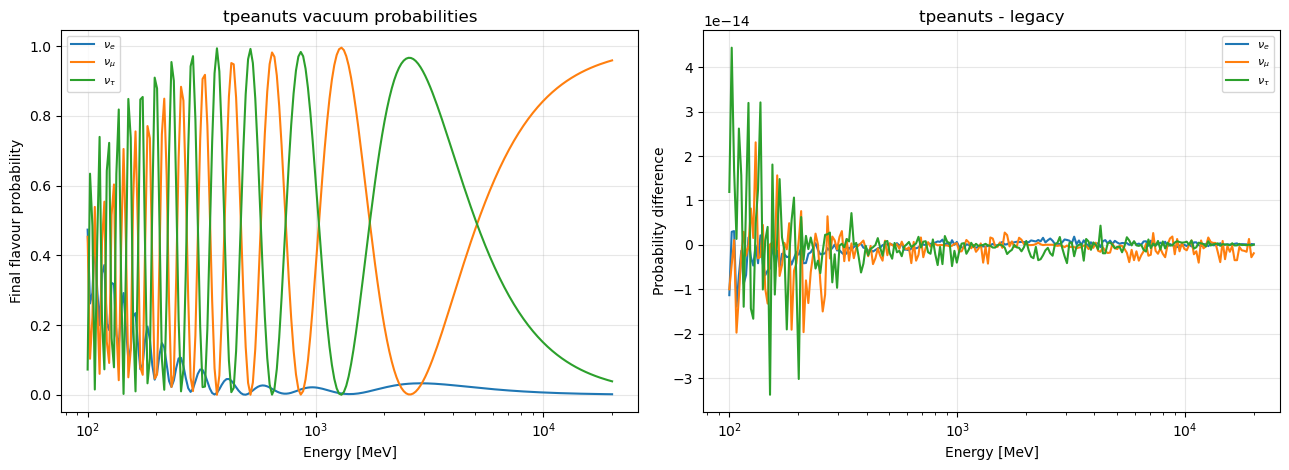

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/vacuum_probabilities_vs_energy.png')

In [5]:
vacuum_rows = []
for baseline in VACUUM_BASELINES_KM:
    for energy in [300.0, 1000.0, 5000.0, 12000.0]:
        for name, state in FLAVOUR_STATES.items():
            t_val = pvacuum(state, pmns, DM21_EV2, DM3L_EV2, energy, baseline, massbasis=False, antinu=False, device=DEVICE, dtype=DTYPE)
            l_val = legacy_pvacuum(to_numpy(state.real), legacy_pmns, DM21_EV2, DM3L_EV2, energy, baseline, antinu=False, massbasis=False)
            rel = relative_error(t_val, l_val)
            vacuum_rows.append(
                f"L={baseline:8.1f} km | E={energy:8.1f} MeV | init={name:5s} | max rel={np.max(rel):.3e}"
            )

print_error_table("Vacuum probability relative errors", vacuum_rows)

# Oscillation probability curves at a fixed baseline.
baseline_plot = 1300.0
initial_plot = FLAVOUR_STATES["numu"]
P_t_vac = pvacuum(initial_plot, pmns, DM21_EV2, DM3L_EV2, VACUUM_ENERGY_GRID_MEV, baseline_plot, massbasis=False, device=DEVICE, dtype=DTYPE)
P_l_vac = np.stack([
    legacy_pvacuum(to_numpy(initial_plot.real), legacy_pmns, DM21_EV2, DM3L_EV2, float(E), baseline_plot, massbasis=False)
    for E in to_numpy(VACUUM_ENERGY_GRID_MEV)
])
print_comparison("Vacuum curve sample, initial numu at L=1300 km", P_t_vac[::50], P_l_vac[::50])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
plot_probability_lines(axes[0], VACUUM_ENERGY_GRID_MEV, P_t_vac, "tpeanuts vacuum probabilities", "Energy [MeV]")
plot_probability_lines(axes[1], VACUUM_ENERGY_GRID_MEV, P_t_vac - torch.as_tensor(P_l_vac, dtype=DTYPE), "tpeanuts - legacy", "Energy [MeV]")
axes[0].set_xscale("log")
axes[1].set_xscale("log")
axes[1].set_ylabel("Probability difference")
fig.tight_layout()
save_and_show("vacuum_probabilities_vs_energy.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 3.2 Flux Comparison

A synthetic three-flavour flux is propagated through the vacuum probability matrix. This checks whether differences at the probability level remain negligible after applying the probabilities to an energy spectrum.



Vacuum propagated flux at E=100.000 MeV
  tpeanuts: [17201.3251761857 17523.6517516534  8873.7841981223]
  legacy  : [17201.3251761864 17523.6517516539  8873.784198122 ]
  max abs error: 6.330083e-10
  max rel error: 3.679997e-14

Vacuum propagated flux at E=263.196 MeV
  tpeanuts: [1795.1082930845 3395.6433603134  620.4662409618]
  legacy  : [1795.1082930845 3395.6433603134  620.4662409618]
  max abs error: 4.729372e-11
  max rel error: 2.330598e-14

Vacuum propagated flux at E=1123.825 MeV
  tpeanuts: [ 76.6230527829 155.6173164831  48.6615564075]
  legacy  : [ 76.6230527829 155.6173164831  48.6615564075]
  max abs error: 1.989520e-13
  max rel error: 4.088483e-15

Vacuum propagated flux at E=7784.983 MeV
  tpeanuts: [1.0524228086 2.5213504502 0.9553596437]
  legacy  : [1.0524228086 2.5213504502 0.9553596437]
  max abs error: 3.219647e-15
  max rel error: 3.370089e-15

Vacuum propagated flux at E=20000.008 MeV
  tpeanuts: [0.1073013199 0.3711192561 0.0422164014]
  legacy  : [0.10730

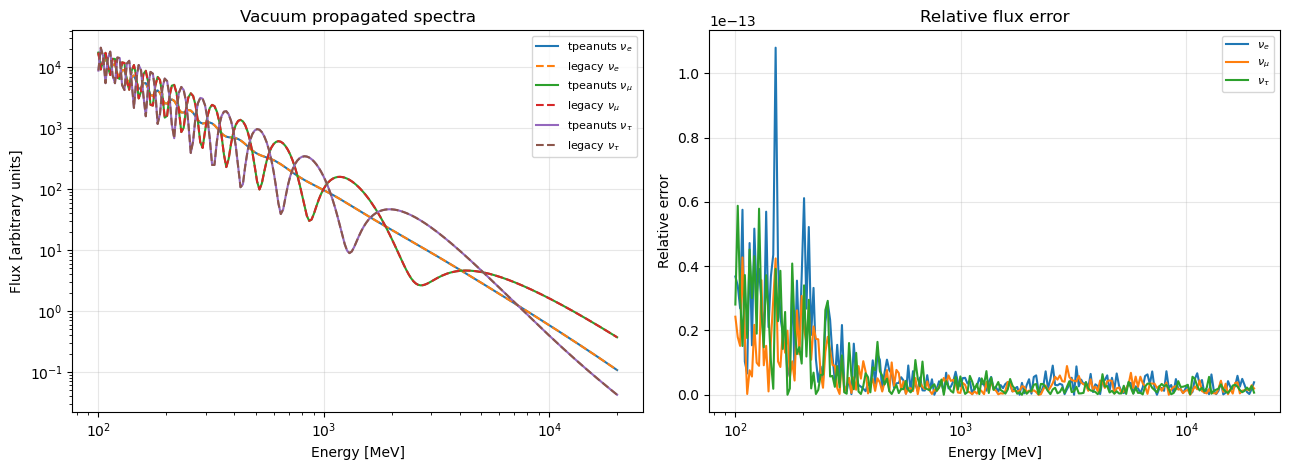

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/vacuum_flux_spectra.png')

In [6]:
vacuum_flux_in = synthetic_flux(VACUUM_ENERGY_GRID_MEV)
baseline_flux = 1300.0
P_t_matrix = vacuum_probability_matrix(pmns, DM21_EV2, DM3L_EV2, VACUUM_ENERGY_GRID_MEV, baseline_flux, device=DEVICE, dtype=DTYPE)
P_l_matrix = legacy_vacuum_probability_matrix(VACUUM_ENERGY_GRID_MEV, baseline_flux)

vacuum_flux_t = apply_probability_matrix_to_flux(P_t_matrix, vacuum_flux_in)
vacuum_flux_l = np.einsum("eba,ea->eb", P_l_matrix, to_numpy(vacuum_flux_in))

for idx in [0, 40, 100, 180, len(VACUUM_ENERGY_GRID_MEV) - 1]:
    print_comparison(
        f"Vacuum propagated flux at E={VACUUM_ENERGY_GRID_MEV[idx].item():.3f} MeV",
        vacuum_flux_t[idx],
        vacuum_flux_l[idx],
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].loglog(to_numpy(VACUUM_ENERGY_GRID_MEV), to_numpy(vacuum_flux_t[:, i]), label=f"tpeanuts {label}")
    axes[0].loglog(to_numpy(VACUUM_ENERGY_GRID_MEV), vacuum_flux_l[:, i], "--", label=f"legacy {label}")
    axes[1].semilogx(to_numpy(VACUUM_ENERGY_GRID_MEV), relative_error(vacuum_flux_t[:, i], vacuum_flux_l[:, i]), label=label)
axes[0].set_title("Vacuum propagated spectra")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Flux [arbitrary units]")
axes[1].set_title("Relative flux error")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Relative error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("vacuum_flux_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 4. Solar Production

This section compares `tpeanuts.solar` against the solar-production part of legacy `peanuts`. The benchmark covers both the solar flavour probabilities and the corresponding source-weighted flux spectra.


### 4.1 Solar Probability Spectra by Source

This diagnostic compares the solar-production probability spectra for all available solar neutrino sources. The first grid uses the torch-native `tpeanuts.solar` implementation; the second grid uses legacy `peanuts`. For the `8B` and `hep` panels, the SNO electron-survival reference from `SNO_8B.csv` and `SNO_hep.csv` is overlaid.


Saved figure: V:\output\benchmark\0_tpeanuts_vs_peanuts_precision\solar_probability_spectra_by_source_tpeanuts.png


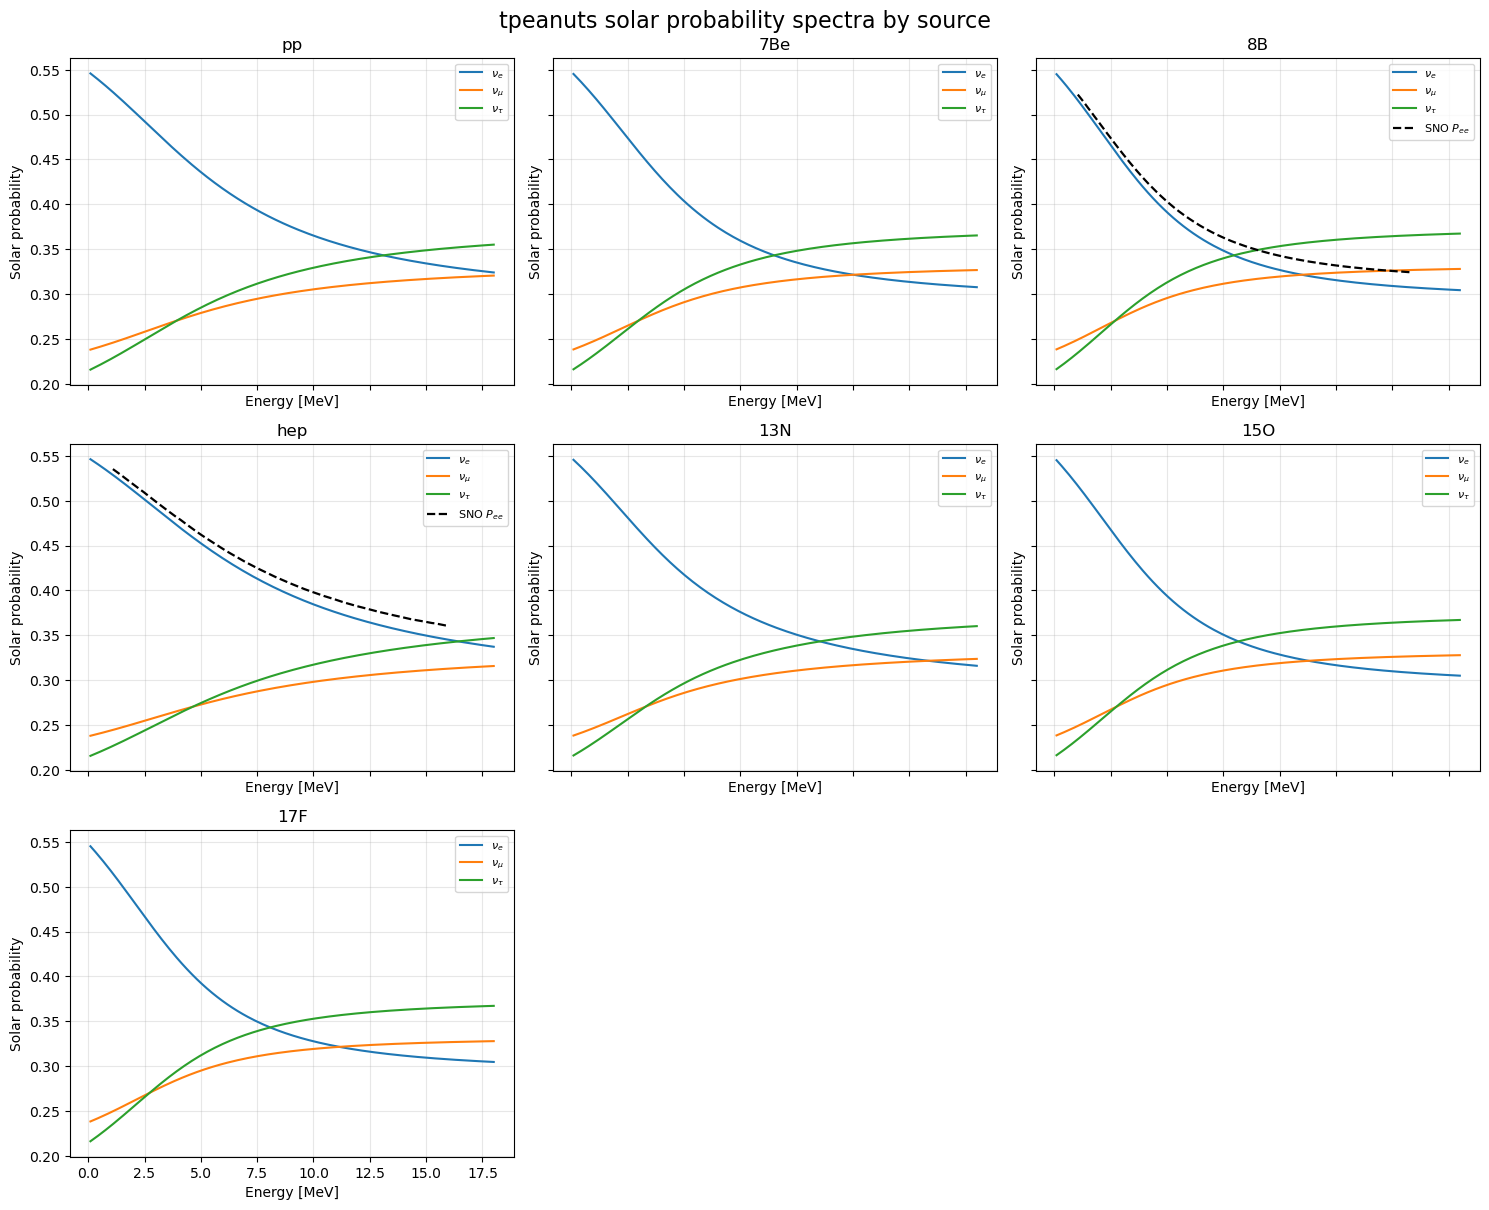

Saved figure: V:\output\benchmark\0_tpeanuts_vs_peanuts_precision\solar_probability_spectra_by_source_legacy.png


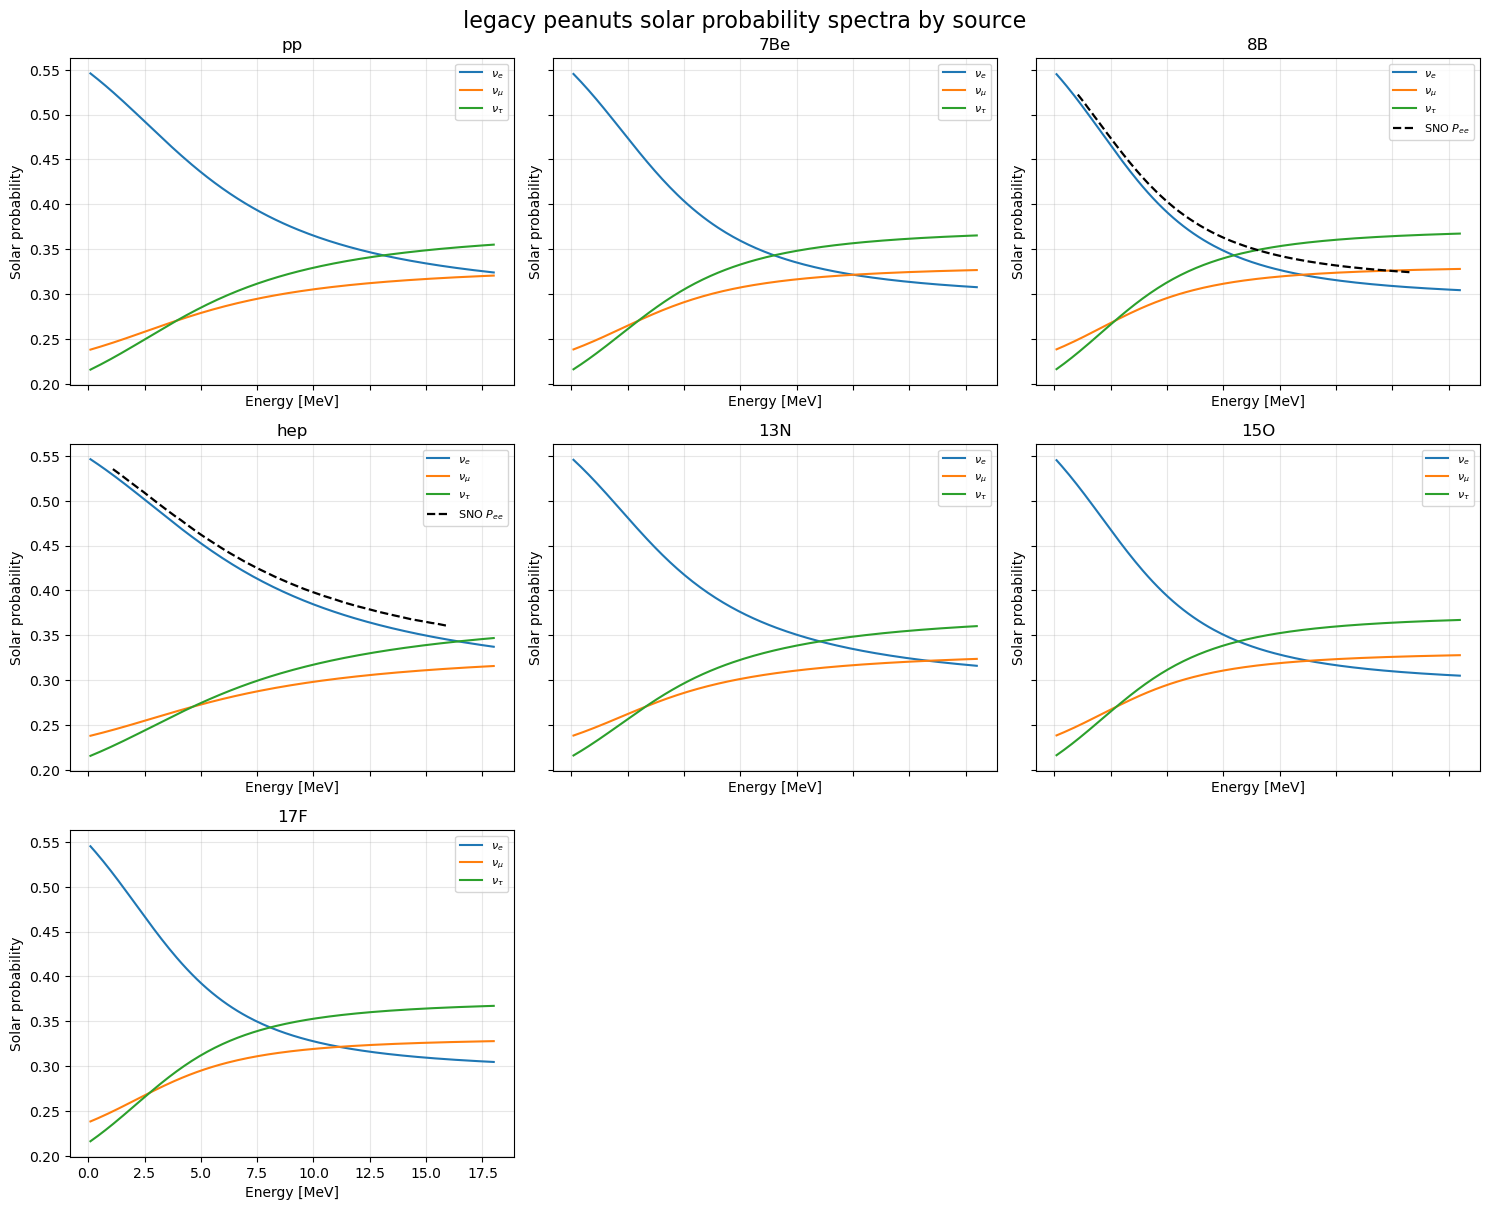

In [7]:

solar_profile = load_default_solar_profile(device=DEVICE, dtype=DTYPE)
legacy_pmns_module, legacy_solar_module = legacy_modules()
legacy_model = legacy_solar_module.SolarModel(
    solar_model_file=str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat"),
    flux_file=str(LEGACY_DATA_DIR / "fluxes_b16.dat"),
    spectrum_files={
        "8B": str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
        "hep": str(LEGACY_DATA_DIR / "hep_shape.csv"),
        "pp": str(LEGACY_DATA_DIR / "pp_shape.csv"),
        "17F": str(LEGACY_DATA_DIR / "f17_shape.csv"),
        "7Beground": str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
        "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
        "13N": str(LEGACY_DATA_DIR / "n13_shape.csv"),
        "15O": str(LEGACY_DATA_DIR / "o15_shape.csv"),
    },
)
legacy_pmns_solar = legacy_pmns_module.PMNS(THETA12, THETA13, THETA23, DELTA_CP)

SOLAR_SOURCE_ORDER = [
    source
    for source in ["pp", "7Be", "8B", "hep", "13N", "15O", "17F"]
    if source in solar_profile.fractions
]
SOLAR_SPECTRUM_ENERGY_MEV = torch.linspace(0.1, 18.0, 160, dtype=DTYPE, device=DEVICE)
SNO_REFERENCE_FILES = {
    "8B": DATA_DIR / "solar" / "SNO_8B.csv",
    "hep": DATA_DIR / "solar" / "SNO_hep.csv",
}


def load_sno_reference(source):
    path = SNO_REFERENCE_FILES.get(source)
    if path is None or not path.exists():
        return None
    table = np.genfromtxt(path, delimiter=",", names=True)
    return table["energy"], table["Pnuenue"]


def plot_solar_source_grid(probabilities_by_source, title, filename):
    n_sources = len(SOLAR_SOURCE_ORDER)
    ncols = 3
    nrows = int(np.ceil(n_sources / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.1 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(-1)

    for ax, source in zip(axes, SOLAR_SOURCE_ORDER):
        probs = probabilities_by_source[source]
        for i, label in enumerate(FLAVOUR_LABELS):
            ax.plot(
                to_numpy(SOLAR_SPECTRUM_ENERGY_MEV),
                to_numpy(probs[:, i]),
                label=label,
            )
        sno = load_sno_reference(source)
        if sno is not None:
            ax.plot(sno[0], sno[1], "k--", lw=1.6, label="SNO $P_{ee}$")
        ax.set_title(source)
        ax.set_xlabel("Energy [MeV]")
        ax.set_ylabel("Solar probability")
        ax.legend(fontsize=8)

    for ax in axes[n_sources:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


tpeanuts_solar_probabilities_by_source = {}
legacy_solar_probabilities_by_source = {}

for source in SOLAR_SOURCE_ORDER:
    tpeanuts_solar_probabilities_by_source[source] = psolar(
        pmns,
        DM21_EV2,
        DM3L_EV2,
        SOLAR_SPECTRUM_ENERGY_MEV,
        solar_profile.radius,
        solar_profile.density,
        solar_profile.production_fraction(source),
    )

    legacy_solar_probabilities_by_source[source] = torch.as_tensor(
        np.stack([
            legacy_solar_module.Psolar(
                legacy_pmns_solar,
                DM21_EV2,
                DM3L_EV2,
                float(energy),
                legacy_model.radius(),
                legacy_model.density(),
                legacy_model.fraction(source),
            )
            for energy in to_numpy(SOLAR_SPECTRUM_ENERGY_MEV)
        ]),
        dtype=DTYPE,
        device=DEVICE,
    )

plot_solar_source_grid(
    tpeanuts_solar_probabilities_by_source,
    "tpeanuts solar probability spectra by source",
    "solar_probability_spectra_by_source_tpeanuts.png",
)
plot_solar_source_grid(
    legacy_solar_probabilities_by_source,
    "legacy peanuts solar probability spectra by source",
    "solar_probability_spectra_by_source_legacy.png",
)


### 4.2 Probability Comparison

The solar comparison uses the same source distribution in both implementations and reports the relative error for `Psolar` over a set of energies and solar sources.



Solar production probability relative errors
--------------------------------------------
source=pp   | E= 0.862 MeV | max rel=1.706e-15
source=pp   | E= 1.000 MeV | max rel=1.132e-15
source=pp   | E= 5.000 MeV | max rel=2.292e-15
source=pp   | E=10.000 MeV | max rel=1.348e-15
source=pp   | E=14.000 MeV | max rel=3.521e-16
source=7Be  | E= 0.862 MeV | max rel=3.751e-15
source=7Be  | E= 1.000 MeV | max rel=4.189e-15
source=7Be  | E= 5.000 MeV | max rel=2.337e-15
source=7Be  | E=10.000 MeV | max rel=3.188e-15
source=7Be  | E=14.000 MeV | max rel=4.471e-15
source=8B   | E= 0.862 MeV | max rel=1.442e-15
source=8B   | E= 1.000 MeV | max rel=5.936e-16
source=8B   | E= 5.000 MeV | max rel=7.511e-16
source=8B   | E=10.000 MeV | max rel=1.042e-15
source=8B   | E=14.000 MeV | max rel=1.834e-15
source=13N  | E= 0.862 MeV | max rel=6.325e-16
source=13N  | E= 1.000 MeV | max rel=2.700e-15
source=13N  | E= 5.000 MeV | max rel=1.498e-15
source=13N  | E=10.000 MeV | max rel=6.559e-16
source=13N  | E=

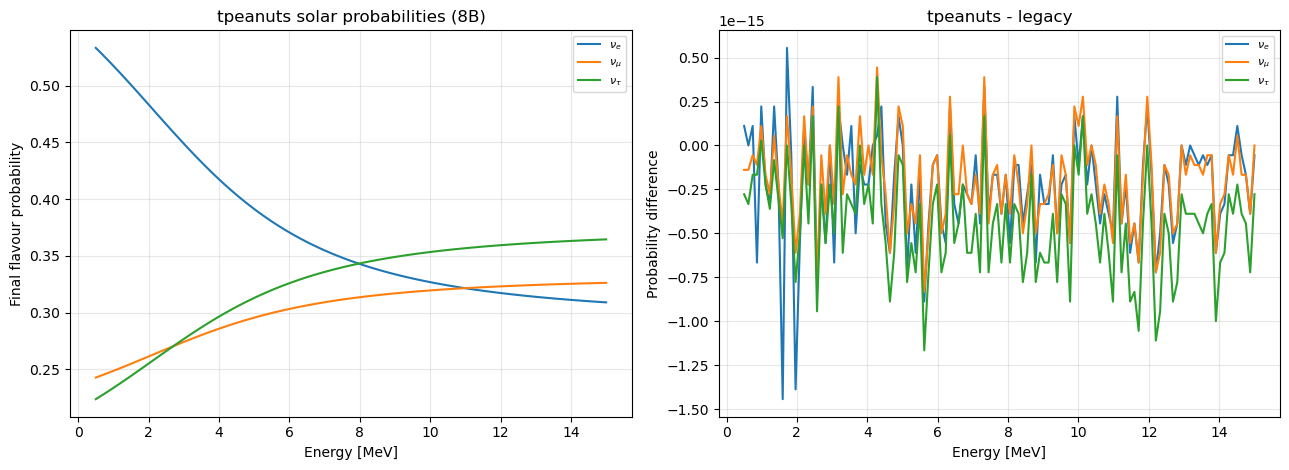

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/solar_probabilities_vs_energy.png')

In [8]:
solar_profile = load_default_solar_profile(device=DEVICE, dtype=DTYPE)
legacy_pmns_module, legacy_solar_module = legacy_modules()
legacy_model = legacy_solar_module.SolarModel(
    solar_model_file=str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat"),
    flux_file=str(LEGACY_DATA_DIR / "fluxes_b16.dat"),
    spectrum_files={
        "8B": str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
        "hep": str(LEGACY_DATA_DIR / "hep_shape.csv"),
        "pp": str(LEGACY_DATA_DIR / "pp_shape.csv"),
        "17F": str(LEGACY_DATA_DIR / "f17_shape.csv"),
        "7Beground": str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
        "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
        "13N": str(LEGACY_DATA_DIR / "n13_shape.csv"),
        "15O": str(LEGACY_DATA_DIR / "o15_shape.csv"),
    },
)
legacy_pmns_solar = legacy_pmns_module.PMNS(THETA12, THETA13, THETA23, DELTA_CP)

solar_rows = []
for source in ["pp", "7Be", "8B", "13N", "15O"]:
    for energy in [0.862, 1.0, 5.0, 10.0, 14.0]:
        fraction_t = solar_profile.production_fraction(source if source != "7Be" else "7Be")
        t_prob = psolar(pmns, DM21_EV2, DM3L_EV2, torch.tensor(energy, dtype=DTYPE), solar_profile.radius, solar_profile.density, fraction_t)
        l_prob = legacy_solar_module.Psolar(
            legacy_pmns_solar,
            DM21_EV2,
            DM3L_EV2,
            energy,
            legacy_model.radius(),
            legacy_model.density(),
            legacy_model.fraction(source),
        )
        rel = relative_error(t_prob, l_prob)
        solar_rows.append(f"source={source:4s} | E={energy:6.3f} MeV | max rel={np.max(rel):.3e}")

print_error_table("Solar production probability relative errors", solar_rows)

P_t_solar = psolar(pmns, DM21_EV2, DM3L_EV2, SOLAR_ENERGY_GRID_MEV, solar_profile.radius, solar_profile.density, solar_profile.production_fraction(SOLAR_SOURCE))
P_l_solar = np.stack([
    legacy_solar_module.Psolar(
        legacy_pmns_solar,
        DM21_EV2,
        DM3L_EV2,
        float(E),
        legacy_model.radius(),
        legacy_model.density(),
        legacy_model.fraction(SOLAR_SOURCE),
    )
    for E in to_numpy(SOLAR_ENERGY_GRID_MEV)
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
plot_probability_lines(axes[0], SOLAR_ENERGY_GRID_MEV, P_t_solar, f"tpeanuts solar probabilities ({SOLAR_SOURCE})", "Energy [MeV]")
plot_probability_lines(axes[1], SOLAR_ENERGY_GRID_MEV, P_t_solar - torch.as_tensor(P_l_solar, dtype=DTYPE), "tpeanuts - legacy", "Energy [MeV]")
axes[1].set_ylabel("Probability difference")
fig.tight_layout()
save_and_show("solar_probabilities_vs_energy.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 4.3 Flux Comparison

Solar mass-eigenstate production weights are multiplied by a synthetic source spectrum. This gives a flux-level check for the solar production block before Earth propagation is applied.



Solar mass flux at E=0.500 MeV
  tpeanuts: [0.0093279352 0.0050078968 0.0003292316]
  legacy  : [0.0093279352 0.0050078968 0.0003292316]
  max abs error: 9.540979e-18
  max rel error: 1.905187e-15

Solar mass flux at E=2.937 MeV
  tpeanuts: [0.1494134127 0.2016982237 0.0082804518]
  legacy  : [0.1494134127 0.2016982237 0.0082804518]
  max abs error: 1.734723e-17
  max rel error: 2.094962e-15

Solar mass flux at E=7.811 MeV
  tpeanuts: [0.1317726347 0.8429371989 0.0242664419]
  legacy  : [0.1317726347 0.8429371989 0.0242664419]
  max abs error: 1.221245e-15
  max rel error: 1.448798e-15

Solar mass flux at E=12.685 MeV
  tpeanuts: [0.0226536193 0.3980438706 0.0110729927]
  legacy  : [0.0226536193 0.3980438706 0.0110729927]
  max abs error: 6.661338e-16
  max rel error: 1.673519e-15

Solar mass flux at E=15.000 MeV
  tpeanuts: [0.0020435315 0.0514468463 0.0014463847]
  legacy  : [0.0020435315 0.0514468463 0.0014463847]
  max abs error: 1.734723e-18
  max rel error: 1.199351e-15
Saved fi

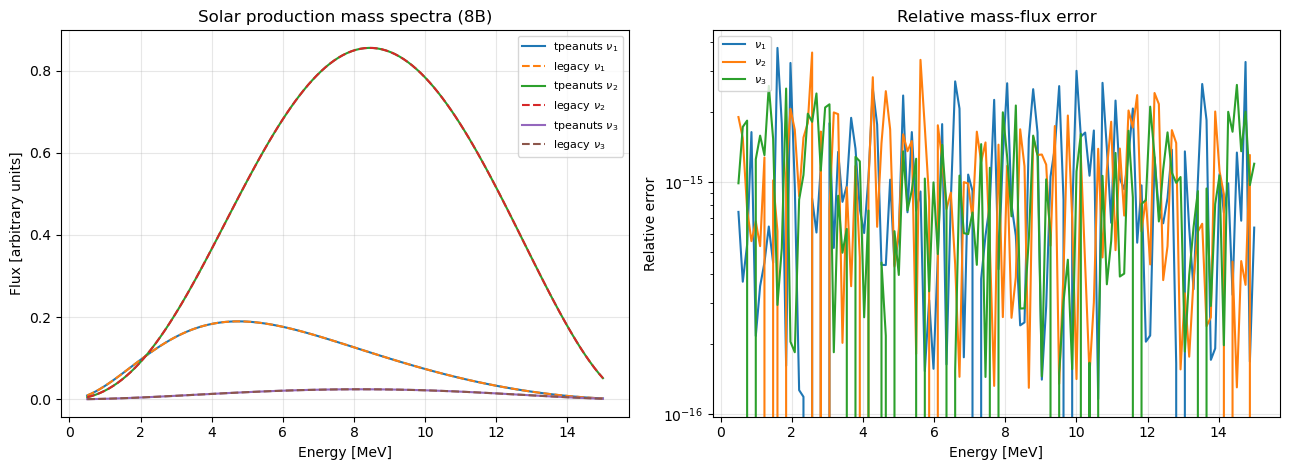

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/solar_flux_spectra.png')

In [9]:
def solar_source_spectrum(E_MeV):
    E = torch.as_tensor(E_MeV, dtype=DTYPE, device=DEVICE)
    if SOLAR_SOURCE == "8B":
        shape = torch.clamp(E * (16.0 - E), min=0.0) ** 2
        shape = shape / torch.max(shape).clamp_min(1.0e-30)
        return shape
    return torch.ones_like(E)

solar_spectrum = solar_source_spectrum(SOLAR_ENERGY_GRID_MEV)
solar_mass_t = solar_flux_mass(
    pmns.theta12,
    pmns.theta13,
    DM21_EV2,
    DM3L_EV2,
    SOLAR_ENERGY_GRID_MEV,
    solar_profile.radius,
    solar_profile.density,
    solar_profile.production_fraction(SOLAR_SOURCE),
)
solar_mass_l = np.stack([
    legacy_solar_module.solar_flux_mass(
        legacy_pmns_solar.theta12,
        legacy_pmns_solar.theta13,
        DM21_EV2,
        DM3L_EV2,
        float(E),
        legacy_model.radius(),
        legacy_model.density(),
        legacy_model.fraction(SOLAR_SOURCE),
    )
    for E in to_numpy(SOLAR_ENERGY_GRID_MEV)
])

solar_mass_flux_t = solar_mass_t * solar_spectrum[:, None]
solar_mass_flux_l = solar_mass_l * to_numpy(solar_spectrum)[:, None]

for idx in [0, 20, 60, 100, len(SOLAR_ENERGY_GRID_MEV) - 1]:
    print_comparison(
        f"Solar mass flux at E={SOLAR_ENERGY_GRID_MEV[idx].item():.3f} MeV",
        solar_mass_flux_t[idx],
        solar_mass_flux_l[idx],
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for i, label in enumerate([r"$\nu_1$", r"$\nu_2$", r"$\nu_3$"]):
    axes[0].plot(to_numpy(SOLAR_ENERGY_GRID_MEV), to_numpy(solar_mass_flux_t[:, i]), label=f"tpeanuts {label}")
    axes[0].plot(to_numpy(SOLAR_ENERGY_GRID_MEV), solar_mass_flux_l[:, i], "--", label=f"legacy {label}")
    axes[1].semilogy(to_numpy(SOLAR_ENERGY_GRID_MEV), relative_error(solar_mass_flux_t[:, i], solar_mass_flux_l[:, i]), label=label)
axes[0].set_title(f"Solar production mass spectra ({SOLAR_SOURCE})")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Flux [arbitrary units]")
axes[1].set_title("Relative mass-flux error")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Relative error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("solar_flux_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 5. Earth Propagation to the Detector

This section compares `tpeanuts.earth` with legacy `peanuts.earth`. The torch calculation uses the public `pearth` wrapper, controlled by `EARTH_METHOD = "analytical"` or `"numerical"` in the parameter block. It uses incoherent mass-basis weights, matching the legacy solar-neutrino detector workflow.


### 5.1 TPeanuts Earth Method Comparison

Before comparing with legacy peanuts, this diagnostic compares the two new `tpeanuts.pearth` modes: `analytical` and `numerical`. The printed values report the relative error of the numerical result with respect to the analytical result for representative energy and nadir-angle combinations.



tpeanuts pearth numerical vs analytical relative errors
-------------------------------------------------------
eta= 0.75 rad | E=  1000.0 MeV | max rel numerical/analytical=1.445e-02
eta= 0.75 rad | E=  8000.0 MeV | max rel numerical/analytical=1.548e-03
Saved figure: V:\output\benchmark\0_tpeanuts_vs_peanuts_precision\earth_tpeanuts_method_comparison.png


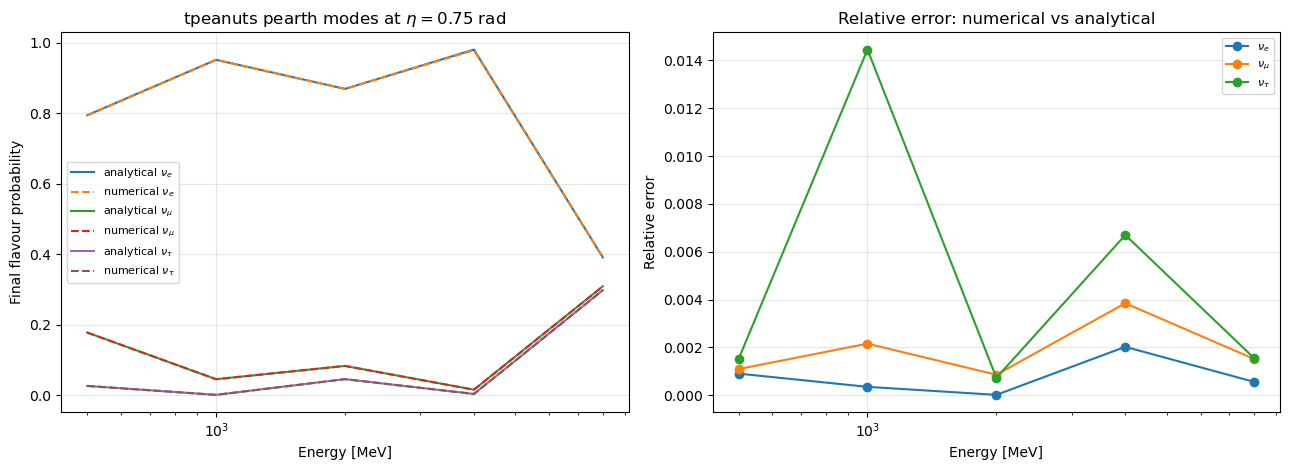

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/earth_tpeanuts_method_comparison.png')

In [10]:
EARTH_DENSITY_TPEANUTS = str( DATA_DIR / "density" / "earth_density.csv" )
EARTH_DENSITY_LEGACY = str( LEGACY_DATA_DIR / "earth_density.csv" )

earth_density_t = load_earth_density_from_csv(EARTH_DENSITY_TPEANUTS, 
                                              tabulated_density=False, 
                                              device=DEVICE, 
                                              dtype=DTYPE
                                             )

method_compare_energies_MeV = torch.tensor([1000.0, 8000.0], dtype=DTYPE, device=DEVICE)
method_compare_etas_rad = torch.tensor([0.75], dtype=DTYPE, device=DEVICE)
method_compare_state = torch.tensor([1.0, 0.0, 0.0], dtype=CDTYPE, device=DEVICE)
method_compare_numerical_steps = 48
_earth_numerical_steps_original = EARTH_NUMERICAL_STEPS
EARTH_NUMERICAL_STEPS = method_compare_numerical_steps

method_rows = []
for eta_value in method_compare_etas_rad:
    for energy_value in method_compare_energies_MeV:
        P_analytical = torch_pearth_probability(
            method_compare_state,
            earth_density_t,
            pmns,
            energy_value,
            eta_value,
            DETECTOR_DEPTH_M,
            massbasis=False,
            method="analytical",
        )
        P_numerical = torch_pearth_probability(
            method_compare_state,
            earth_density_t,
            pmns,
            energy_value,
            eta_value,
            DETECTOR_DEPTH_M,
            massbasis=False,
            method="numerical",
        )
        rel = relative_error(P_numerical, P_analytical)
        method_rows.append(
            f"eta={float(eta_value):5.2f} rad | E={float(energy_value):8.1f} MeV | max rel numerical/analytical={np.max(rel):.3e}"
        )

print_error_table("tpeanuts pearth numerical vs analytical relative errors", method_rows)

plot_energies_method_MeV = torch.logspace(
    torch.log10(torch.tensor(500.0, dtype=DTYPE)),
    torch.log10(torch.tensor(8000.0, dtype=DTYPE)),
    5,
    dtype=DTYPE,
    device=DEVICE,
)
plot_eta_method = torch.tensor(0.75, dtype=DTYPE, device=DEVICE)
P_method_analytical = torch.stack([
    torch_pearth_probability(
        method_compare_state,
        earth_density_t,
        pmns,
        energy_value,
        plot_eta_method,
        DETECTOR_DEPTH_M,
        massbasis=False,
        method="analytical",
    )
    for energy_value in plot_energies_method_MeV
])
P_method_numerical = torch.stack([
    torch_pearth_probability(
        method_compare_state,
        earth_density_t,
        pmns,
        energy_value,
        plot_eta_method,
        DETECTOR_DEPTH_M,
        massbasis=False,
        method="numerical",
    )
    for energy_value in plot_energies_method_MeV
])
method_rel_curve = relative_error(P_method_numerical, P_method_analytical)

EARTH_NUMERICAL_STEPS = _earth_numerical_steps_original

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].semilogx(to_numpy(plot_energies_method_MeV), to_numpy(P_method_analytical[:, i]), label=f"analytical {label}")
    axes[0].semilogx(to_numpy(plot_energies_method_MeV), to_numpy(P_method_numerical[:, i]), "--", label=f"numerical {label}")
    axes[1].semilogx(to_numpy(plot_energies_method_MeV), method_rel_curve[:, i], marker="o", label=label)
axes[0].set_title(rf"tpeanuts pearth modes at $\eta={float(plot_eta_method):.2f}$ rad")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Final flavour probability")
axes[1].set_title("Relative error: numerical vs analytical")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Relative error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("earth_tpeanuts_method_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 5.2 Probability Comparison

The Earth block is checked for several energies and nadir angles using `pearth` with the configurable `EARTH_METHOD` parameter. The diagnostic includes both direct printed relative errors and oscillation curves as functions of nadir angle and energy.


Using tpeanuts pearth method: analytical

Earth propagation probability relative errors
---------------------------------------------
eta= 0.35 rad | E=   500.0 MeV | max rel=9.436e-15
eta= 0.35 rad | E=  1000.0 MeV | max rel=1.369e-14
eta= 0.35 rad | E=  5000.0 MeV | max rel=2.831e-15
eta= 0.35 rad | E= 10000.0 MeV | max rel=2.012e-14
eta= 0.75 rad | E=   500.0 MeV | max rel=2.624e-14
eta= 0.75 rad | E=  1000.0 MeV | max rel=1.825e-14
eta= 0.75 rad | E=  5000.0 MeV | max rel=4.117e-15
eta= 0.75 rad | E= 10000.0 MeV | max rel=1.704e-14
eta= 1.20 rad | E=   500.0 MeV | max rel=1.419e-14
eta= 1.20 rad | E=  1000.0 MeV | max rel=3.152e-15
eta= 1.20 rad | E=  5000.0 MeV | max rel=3.428e-15
eta= 1.20 rad | E= 10000.0 MeV | max rel=1.866e-14
eta= 2.40 rad | E=   500.0 MeV | max rel=2.882e-16
eta= 2.40 rad | E=  1000.0 MeV | max rel=2.882e-16
eta= 2.40 rad | E=  5000.0 MeV | max rel=2.882e-16
eta= 2.40 rad | E= 10000.0 MeV | max rel=2.882e-16
Saved figure: V:\output\benchmark\0_tpeanuts_vs_pe

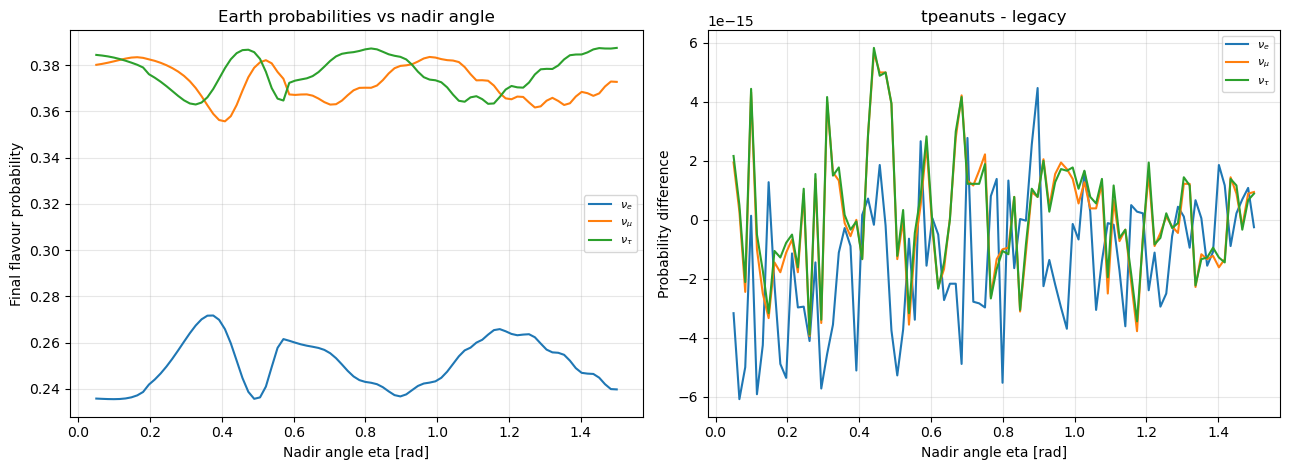

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/earth_probabilities_vs_eta.png')

In [11]:
earth_density_t = load_earth_density_from_csv(str(EARTH_DENSITY_TPEANUTS), tabulated_density=False, device=DEVICE, dtype=DTYPE)
earth_density_l = LegacyEarthDensity(density_file=str(EARTH_DENSITY_LEGACY), tabulated_density=False)

mass_weights_np = to_numpy(MASS_WEIGHTS)
earth_rows = []
for eta in EARTH_ETA_VALUES_RAD:
    for energy in [500.0, 1000.0, 5000.0, 10000.0]:
        t_prob = torch_pearth_probability(
            MASS_WEIGHTS,
            earth_density_t,
            pmns,
            torch.tensor(energy, dtype=DTYPE),
            torch.tensor(eta, dtype=DTYPE),
            DETECTOR_DEPTH_M,
            massbasis=True,
        )
        l_prob = legacy_pearth(
            mass_weights_np,
            earth_density_l,
            legacy_pmns,
            DM21_EV2,
            DM3L_EV2,
            energy,
            eta,
            DETECTOR_DEPTH_M,
            mode=EARTH_METHOD,
            massbasis=True,
        )
        rel = relative_error(t_prob, l_prob)
        earth_rows.append(f"eta={eta:5.2f} rad | E={energy:8.1f} MeV | max rel={np.max(rel):.3e}")

print(f"Using tpeanuts pearth method: {EARTH_METHOD}")
print_error_table("Earth propagation probability relative errors", earth_rows)

eta_plot = torch.linspace(0.05, 1.50, 90, dtype=DTYPE, device=DEVICE)
E_plot = torch.tensor(1000.0, dtype=DTYPE, device=DEVICE)
P_t_eta = torch_pearth_probability(MASS_WEIGHTS, earth_density_t, pmns, E_plot, eta_plot, DETECTOR_DEPTH_M, massbasis=True)
P_l_eta = np.stack([
    legacy_pearth(mass_weights_np, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2, float(E_plot), float(eta), DETECTOR_DEPTH_M, mode="analytical", massbasis=True)
    for eta in to_numpy(eta_plot)
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
plot_probability_lines(axes[0], eta_plot, P_t_eta, "Earth probabilities vs nadir angle", "Nadir angle eta [rad]")
plot_probability_lines(axes[1], eta_plot, P_t_eta - torch.as_tensor(P_l_eta, dtype=DTYPE), "tpeanuts - legacy", "Nadir angle eta [rad]")
axes[1].set_ylabel("Probability difference")
fig.tight_layout()
save_and_show("earth_probabilities_vs_eta.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 5.3 Flux Comparison

The same synthetic input spectra are propagated through the Earth block. Each initial flavour spectrum is interpreted as an incoherent mass-weighted spectrum for this detector-level diagnostic.



Earth propagated flux at E=100.000 MeV, eta=0.75
  tpeanuts: [22671.4033102879 10478.5726828506 10594.2667895476]
  legacy  : [22671.4033102874 10478.5726828503 10594.2667895467]
  max abs error: 9.385985e-10
  max rel error: 8.859495e-14

Earth propagated flux at E=304.376 MeV, eta=0.75
  tpeanuts: [2313.9257520344  892.6493489727 1096.729896529 ]
  legacy  : [2313.9257520342  892.6493489728 1096.729896529 ]
  max abs error: 1.086846e-10
  max rel error: 4.696979e-14

Earth propagated flux at E=1446.050 MeV, eta=0.75
  tpeanuts: [69.5832250462 42.8245669144 53.1811624441]
  legacy  : [69.5832250462 42.8245669144 53.1811624441]
  max abs error: 4.831691e-13
  max rel error: 7.348439e-15

Earth propagated flux at E=5498.888 MeV, eta=0.75
  tpeanuts: [1.5483675164 2.3416893917 5.7964443774]
  legacy  : [1.5483675164 2.3416893917 5.7964443774]
  max abs error: 5.062617e-14
  max rel error: 1.232691e-14

Earth propagated flux at E=20000.008 MeV, eta=0.75
  tpeanuts: [0.1914468767 0.168933

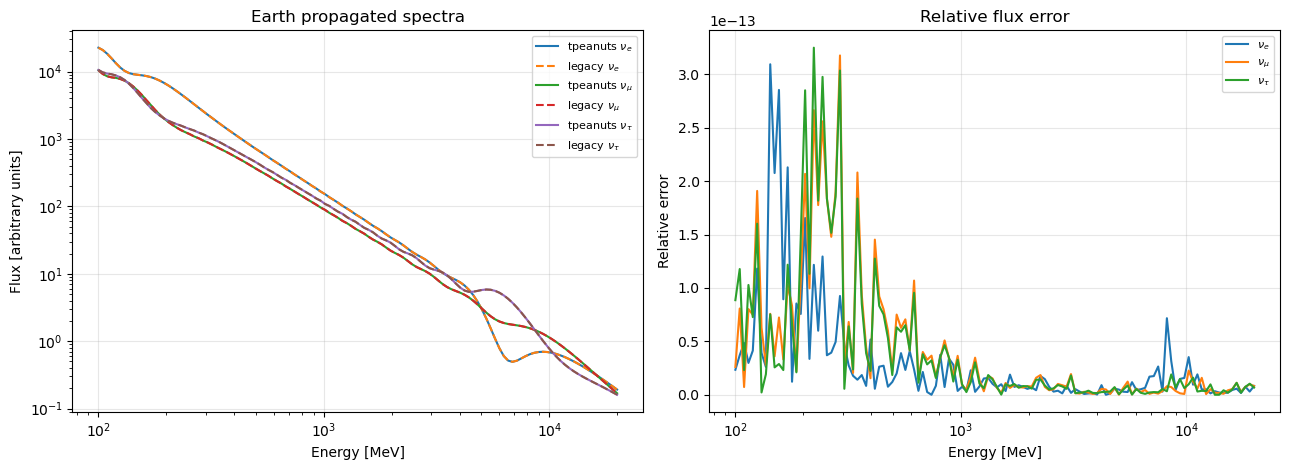

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/earth_flux_spectra.png')

In [12]:
earth_flux_in = synthetic_flux(EARTH_ENERGY_GRID_MEV)
eta_flux = 0.75

# Build a response matrix by propagating the three unit mass states; columns are initial mass eigenstates.
P_t_mass_columns = []
P_l_mass_columns = []
for i in range(3):
    state_t = torch.eye(3, dtype=DTYPE, device=DEVICE)[i]
    state_l = np.eye(3)[i]
    P_t_i = torch_pearth_probability(state_t, earth_density_t, pmns, EARTH_ENERGY_GRID_MEV, torch.tensor(eta_flux, dtype=DTYPE), DETECTOR_DEPTH_M, massbasis=True)
    P_l_i = np.stack([
        legacy_pearth(state_l, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2, float(E), eta_flux, DETECTOR_DEPTH_M, mode="analytical", massbasis=True)
        for E in to_numpy(EARTH_ENERGY_GRID_MEV)
    ])
    P_t_mass_columns.append(P_t_i)
    P_l_mass_columns.append(P_l_i)

P_t_earth_matrix = torch.stack(P_t_mass_columns, dim=-1)
P_l_earth_matrix = np.stack(P_l_mass_columns, axis=-1)
earth_flux_t = torch.einsum("eba,ea->eb", P_t_earth_matrix, earth_flux_in)
earth_flux_l = np.einsum("eba,ea->eb", P_l_earth_matrix, to_numpy(earth_flux_in))

for idx in [0, 25, 60, 90, len(EARTH_ENERGY_GRID_MEV) - 1]:
    print_comparison(
        f"Earth propagated flux at E={EARTH_ENERGY_GRID_MEV[idx].item():.3f} MeV, eta={eta_flux:.2f}",
        earth_flux_t[idx],
        earth_flux_l[idx],
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].loglog(to_numpy(EARTH_ENERGY_GRID_MEV), to_numpy(earth_flux_t[:, i]), label=f"tpeanuts {label}")
    axes[0].loglog(to_numpy(EARTH_ENERGY_GRID_MEV), earth_flux_l[:, i], "--", label=f"legacy {label}")
    axes[1].semilogx(to_numpy(EARTH_ENERGY_GRID_MEV), relative_error(earth_flux_t[:, i], earth_flux_l[:, i]), label=label)
axes[0].set_title("Earth propagated spectra")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Flux [arbitrary units]")
axes[1].set_title("Relative flux error")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Relative error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("earth_flux_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Integrated Probabilities

This section compares the full integrated solar-to-detector workflow. It checks the integrated detector probabilities after weighting the Earth propagation by the nadir exposure.


Using tpeanuts pearth method for integrated probabilities: analytical

Integrated detector probability at E=1.000 MeV
  tpeanuts: [0.5172645208 0.2488713455 0.2338643089]
  legacy  : [0.5172645208 0.2488713455 0.2338643089]
  max abs error: 3.298917e-12
  max rel error: 6.377620e-12

Integrated detector probability at E=3.000 MeV
  tpeanuts: [0.4493250217 0.2740235497 0.2766527188]
  legacy  : [0.4493250217 0.2740235497 0.2766527188]
  max abs error: 7.359113e-13
  max rel error: 1.637815e-12

Integrated detector probability at E=5.000 MeV
  tpeanuts: [0.3923823382 0.2951697412 0.312453506 ]
  legacy  : [0.3923823382 0.2951697412 0.312453506 ]
  max abs error: 2.899347e-13
  max rel error: 9.279292e-13

Integrated detector probability at E=8.000 MeV
  tpeanuts: [0.3476649987 0.311046356  0.3413020013]
  legacy  : [0.3476649987 0.311046356  0.3413020013]
  max abs error: 2.785550e-13
  max rel error: 8.161539e-13

Integrated detector probability at E=12.000 MeV
  tpeanuts: [0.3227973467

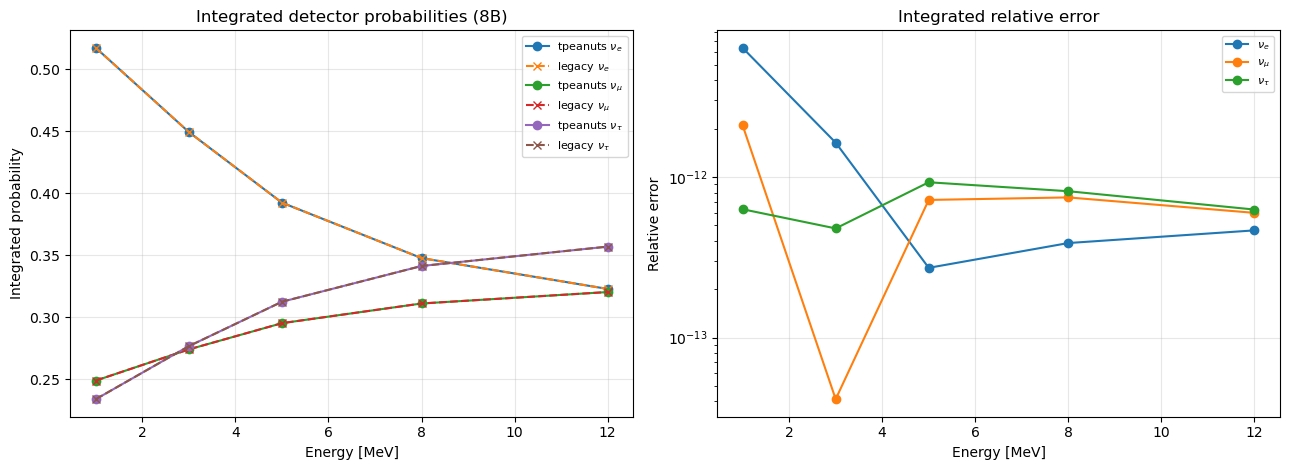

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/integrated_detector_probabilities.png')

In [13]:
integrated_E = torch.tensor([1.0, 3.0, 5.0, 8.0, 12.0], dtype=DTYPE, device=DEVICE)
eta_integrated = torch.linspace(0.02, math.pi - 0.02, EXPOSURE_NS, dtype=DTYPE, device=DEVICE)
exposure_integrated = torch.ones_like(eta_integrated)
exposure_integrated = exposure_integrated / torch.trapezoid(exposure_integrated, x=eta_integrated).clamp_min(torch.finfo(DTYPE).tiny)

mass_weights_t_integrated = solar_flux_mass(
    pmns.theta12,
    pmns.theta13,
    DM21_EV2,
    DM3L_EV2,
    integrated_E,
    solar_profile.radius,
    solar_profile.density,
    solar_profile.production_fraction(SOLAR_SOURCE),
)

mass_weights_l_integrated = np.stack([
    legacy_solar_module.solar_flux_mass(
        legacy_pmns_solar.theta12,
        legacy_pmns_solar.theta13,
        DM21_EV2,
        DM3L_EV2,
        float(E),
        legacy_model.radius(),
        legacy_model.density(),
        legacy_model.fraction(SOLAR_SOURCE),
    )
    for E in to_numpy(integrated_E)
])

P_eta_t = []
P_eta_l = []
for i_E, energy in enumerate(integrated_E):
    probs_t_one_energy = []
    probs_l_one_energy = []
    for eta in eta_integrated:
        probs_t_one_energy.append(
            torch_pearth_probability(
                mass_weights_t_integrated[i_E],
                earth_density_t,
                pmns,
                energy,
                eta,
                DETECTOR_DEPTH_M,
                massbasis=True,
            )
        )
        probs_l_one_energy.append(
            legacy_pearth(
                mass_weights_l_integrated[i_E],
                earth_density_l,
                legacy_pmns,
                DM21_EV2,
                DM3L_EV2,
                float(energy),
                float(eta),
                DETECTOR_DEPTH_M,
                mode="analytical",
                massbasis=True,
            )
        )
    P_eta_t.append(torch.stack(probs_t_one_energy, dim=0))
    P_eta_l.append(np.stack(probs_l_one_energy, axis=0))

P_eta_t = torch.stack(P_eta_t, dim=0)
P_eta_l = np.stack(P_eta_l, axis=0)
P_int_t = torch.trapezoid(P_eta_t * exposure_integrated[None, :, None], x=eta_integrated, dim=1)
P_int_l = np.trapz(P_eta_l * to_numpy(exposure_integrated)[None, :, None], x=to_numpy(eta_integrated), axis=1)

print(f"Using tpeanuts pearth method for integrated probabilities: {EARTH_METHOD}")
for idx, energy in enumerate(integrated_E):
    print_comparison(f"Integrated detector probability at E={energy.item():.3f} MeV", P_int_t[idx], P_int_l[idx])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].plot(to_numpy(integrated_E), to_numpy(P_int_t[:, i]), marker="o", label=f"tpeanuts {label}")
    axes[0].plot(to_numpy(integrated_E), P_int_l[:, i], "--", marker="x", label=f"legacy {label}")
    axes[1].semilogy(to_numpy(integrated_E), relative_error(P_int_t[:, i], P_int_l[:, i]), marker="o", label=label)
axes[0].set_title(f"Integrated detector probabilities ({SOLAR_SOURCE})")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Integrated probability")
axes[1].set_title("Integrated relative error")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Relative error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("integrated_detector_probabilities.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 7. Solar-Detector

This final benchmark follows the complete legacy-style chain from solar neutrino production to detection after Earth propagation. The detector is placed at a depth of 1000 m, so this section checks the same physics blocks as before under an underground-detector configuration.


### 7.1 Probability Comparison

Solar mass-eigenstate production weights are propagated through Earth to a detector at 1000 m depth. The comparison reports relative errors for representative energy and nadir-angle combinations, then visualizes both energy spectra and nadir-angle oscillations.


Using tpeanuts pearth method for solar-detector probabilities: analytical

Solar-detector probability relative errors
------------------------------------------
depth=1000.0 m | E=  1.0 MeV | eta=0.35 rad | max rel=1.961e-11
depth=1000.0 m | E=  1.0 MeV | eta=0.75 rad | max rel=1.411e-11
depth=1000.0 m | E=  1.0 MeV | eta=1.20 rad | max rel=6.941e-12
depth=1000.0 m | E=  1.0 MeV | eta=2.40 rad | max rel=1.974e-14
depth=1000.0 m | E=  3.0 MeV | eta=0.35 rad | max rel=5.141e-12
depth=1000.0 m | E=  3.0 MeV | eta=0.75 rad | max rel=3.134e-12
depth=1000.0 m | E=  3.0 MeV | eta=1.20 rad | max rel=2.103e-12
depth=1000.0 m | E=  3.0 MeV | eta=2.40 rad | max rel=1.684e-14
depth=1000.0 m | E=  5.0 MeV | eta=0.35 rad | max rel=2.162e-12
depth=1000.0 m | E=  5.0 MeV | eta=0.75 rad | max rel=2.221e-12
depth=1000.0 m | E=  5.0 MeV | eta=1.20 rad | max rel=9.794e-13
depth=1000.0 m | E=  5.0 MeV | eta=2.40 rad | max rel=1.011e-14
depth=1000.0 m | E=  8.0 MeV | eta=0.35 rad | max rel=2.389e-12
depth=1

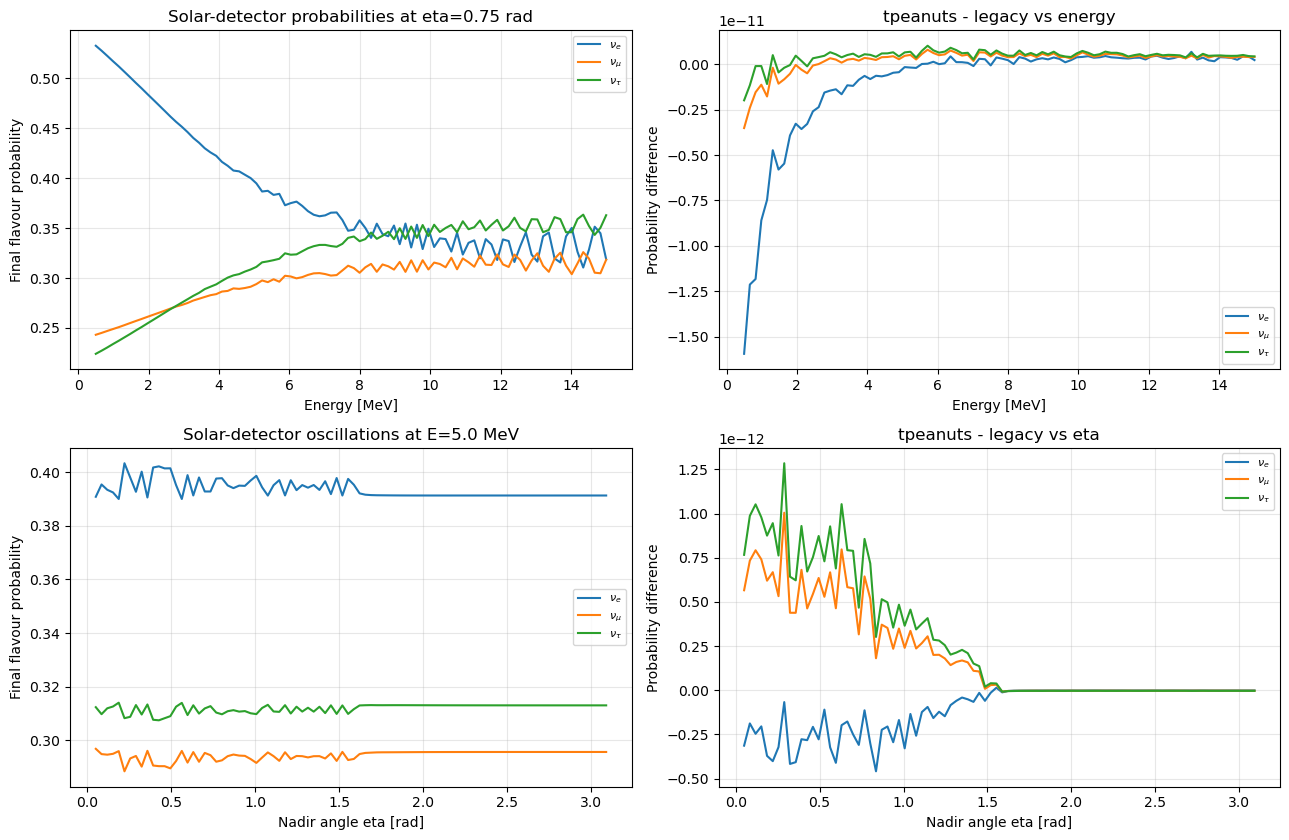

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/solar_detector_probabilities.png')

In [14]:
SOLAR_DETECTOR_DEPTH_M = 1000.0
SOLAR_DETECTOR_SOURCE = SOLAR_SOURCE
SOLAR_DETECTOR_ENERGY_GRID_MEV = torch.linspace(0.5, 15.0, 90, dtype=DTYPE, device=DEVICE)
SOLAR_DETECTOR_ETA_GRID = torch.linspace(0.05, math.pi - 0.05, 90, dtype=DTYPE, device=DEVICE)
SOLAR_DETECTOR_ETA_FIXED = torch.tensor(0.75, dtype=DTYPE, device=DEVICE)

# Ensure the Earth-density and solar-model objects exist even when this section is run after a fresh kernel restart.
earth_density_t = load_earth_density_from_csv(str(EARTH_DENSITY_TPEANUTS), tabulated_density=False, device=DEVICE, dtype=DTYPE)
earth_density_l = LegacyEarthDensity(density_file=str(EARTH_DENSITY_LEGACY), tabulated_density=False)
solar_profile = load_default_solar_profile(device=DEVICE, dtype=DTYPE)
legacy_pmns_module, legacy_solar_module = legacy_modules()
legacy_model = legacy_solar_module.SolarModel(
    solar_model_file=str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat"),
    flux_file=str(LEGACY_DATA_DIR / "fluxes_b16.dat"),
    spectrum_files={
        "8B": str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
        "hep": str(LEGACY_DATA_DIR / "hep_shape.csv"),
        "pp": str(LEGACY_DATA_DIR / "pp_shape.csv"),
        "17F": str(LEGACY_DATA_DIR / "f17_shape.csv"),
        "7Beground": str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
        "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
        "13N": str(LEGACY_DATA_DIR / "n13_shape.csv"),
        "15O": str(LEGACY_DATA_DIR / "o15_shape.csv"),
    },
)
legacy_pmns_solar = legacy_pmns_module.PMNS(THETA12, THETA13, THETA23, DELTA_CP)


def solar_detector_mass_weights_t(E_MeV):
    return solar_flux_mass(
        pmns.theta12,
        pmns.theta13,
        DM21_EV2,
        DM3L_EV2,
        E_MeV,
        solar_profile.radius,
        solar_profile.density,
        solar_profile.production_fraction(SOLAR_DETECTOR_SOURCE),
    )


def solar_detector_mass_weights_l(E_MeV):
    return legacy_solar_module.solar_flux_mass(
        legacy_pmns_solar.theta12,
        legacy_pmns_solar.theta13,
        DM21_EV2,
        DM3L_EV2,
        float(E_MeV),
        legacy_model.radius(),
        legacy_model.density(),
        legacy_model.fraction(SOLAR_DETECTOR_SOURCE),
    )

probability_rows = []
for energy in [1.0, 3.0, 5.0, 8.0, 12.0]:
    mass_t = solar_detector_mass_weights_t(torch.tensor(energy, dtype=DTYPE, device=DEVICE))
    mass_l = solar_detector_mass_weights_l(energy)
    for eta in [0.35, 0.75, 1.20, 2.40]:
        prob_t = torch_pearth_probability(
            mass_t,
            earth_density_t,
            pmns,
            torch.tensor(energy, dtype=DTYPE, device=DEVICE),
            torch.tensor(eta, dtype=DTYPE, device=DEVICE),
            SOLAR_DETECTOR_DEPTH_M,
            massbasis=True,
        )
        prob_l = legacy_pearth(
            mass_l,
            earth_density_l,
            legacy_pmns,
            DM21_EV2,
            DM3L_EV2,
            energy,
            eta,
            SOLAR_DETECTOR_DEPTH_M,
            mode="analytical",
            massbasis=True,
        )
        rel = relative_error(prob_t, prob_l)
        probability_rows.append(
            f"depth={SOLAR_DETECTOR_DEPTH_M:6.1f} m | E={energy:5.1f} MeV | eta={eta:4.2f} rad | max rel={np.max(rel):.3e}"
        )

print(f"Using tpeanuts pearth method for solar-detector probabilities: {EARTH_METHOD}")
print_error_table("Solar-detector probability relative errors", probability_rows)

mass_grid_t = solar_detector_mass_weights_t(SOLAR_DETECTOR_ENERGY_GRID_MEV)
prob_energy_t = []
prob_energy_l = []
for idx, energy in enumerate(SOLAR_DETECTOR_ENERGY_GRID_MEV):
    prob_energy_t.append(
        torch_pearth_probability(
            mass_grid_t[idx],
            earth_density_t,
            pmns,
            energy,
            SOLAR_DETECTOR_ETA_FIXED,
            SOLAR_DETECTOR_DEPTH_M,
            massbasis=True,
        )
    )
    prob_energy_l.append(
        legacy_pearth(
            solar_detector_mass_weights_l(float(energy)),
            earth_density_l,
            legacy_pmns,
            DM21_EV2,
            DM3L_EV2,
            float(energy),
            float(SOLAR_DETECTOR_ETA_FIXED),
            SOLAR_DETECTOR_DEPTH_M,
            mode="analytical",
            massbasis=True,
        )
    )
prob_energy_t = torch.stack(prob_energy_t, dim=0)
prob_energy_l = np.stack(prob_energy_l, axis=0)

E_eta_plot = torch.tensor(5.0, dtype=DTYPE, device=DEVICE)
mass_eta_t = solar_detector_mass_weights_t(E_eta_plot)
mass_eta_l = solar_detector_mass_weights_l(float(E_eta_plot))
prob_eta_t = []
prob_eta_l = []
for eta in SOLAR_DETECTOR_ETA_GRID:
    prob_eta_t.append(
        torch_pearth_probability(
            mass_eta_t,
            earth_density_t,
            pmns,
            E_eta_plot,
            eta,
            SOLAR_DETECTOR_DEPTH_M,
            massbasis=True,
        )
    )
    prob_eta_l.append(
        legacy_pearth(
            mass_eta_l,
            earth_density_l,
            legacy_pmns,
            DM21_EV2,
            DM3L_EV2,
            float(E_eta_plot),
            float(eta),
            SOLAR_DETECTOR_DEPTH_M,
            mode="analytical",
            massbasis=True,
        )
    )
prob_eta_t = torch.stack(prob_eta_t, dim=0)
prob_eta_l = np.stack(prob_eta_l, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
plot_probability_lines(
    axes[0, 0],
    SOLAR_DETECTOR_ENERGY_GRID_MEV,
    prob_energy_t,
    f"Solar-detector probabilities at eta={float(SOLAR_DETECTOR_ETA_FIXED):.2f} rad",
    "Energy [MeV]",
)
plot_probability_lines(
    axes[0, 1],
    SOLAR_DETECTOR_ENERGY_GRID_MEV,
    prob_energy_t - torch.as_tensor(prob_energy_l, dtype=DTYPE),
    "tpeanuts - legacy vs energy",
    "Energy [MeV]",
)
plot_probability_lines(
    axes[1, 0],
    SOLAR_DETECTOR_ETA_GRID,
    prob_eta_t,
    f"Solar-detector oscillations at E={float(E_eta_plot):.1f} MeV",
    "Nadir angle eta [rad]",
)
plot_probability_lines(
    axes[1, 1],
    SOLAR_DETECTOR_ETA_GRID,
    prob_eta_t - torch.as_tensor(prob_eta_l, dtype=DTYPE),
    "tpeanuts - legacy vs eta",
    "Nadir angle eta [rad]",
)
axes[0, 1].set_ylabel("Probability difference")
axes[1, 1].set_ylabel("Probability difference")
fig.tight_layout()
save_and_show("solar_detector_probabilities.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 7.2 Flux Comparison

The detector probabilities are applied to a positive source spectrum to compare final detector fluxes after the full solar-production and Earth-propagation chain.



Solar-detector flux at E=0.500 MeV, depth=1000 m
  tpeanuts: [0.0078127524 0.0035654437 0.0032855157]
  legacy  : [0.0078127524 0.0035654437 0.0032855157]
  max abs error: 2.338962e-13
  max rel error: 2.993775e-11

Solar-detector flux at E=3.758 MeV, depth=1000 m
  tpeanuts: [0.2201006601 0.1461555614 0.1505505886]
  legacy  : [0.2201006601 0.1461555614 0.1505505886]
  max abs error: 4.386214e-13
  max rel error: 1.992822e-12

Solar-detector flux at E=7.831 MeV, depth=1000 m
  tpeanuts: [0.348128296  0.3096831079 0.3413176017]
  legacy  : [0.348128296  0.3096831079 0.3413176017]
  max abs error: 5.914713e-13
  max rel error: 1.732906e-12

Solar-detector flux at E=11.904 MeV, depth=1000 m
  tpeanuts: [0.1845805599 0.1878255884 0.2079492516]
  legacy  : [0.1845805599 0.1878255884 0.2079492516]
  max abs error: 2.595701e-13
  max rel error: 1.248238e-12

Solar-detector flux at E=15.000 MeV, depth=1000 m
  tpeanuts: [0.0175101905 0.0174863141 0.0199380969]
  legacy  : [0.0175101905 0.017

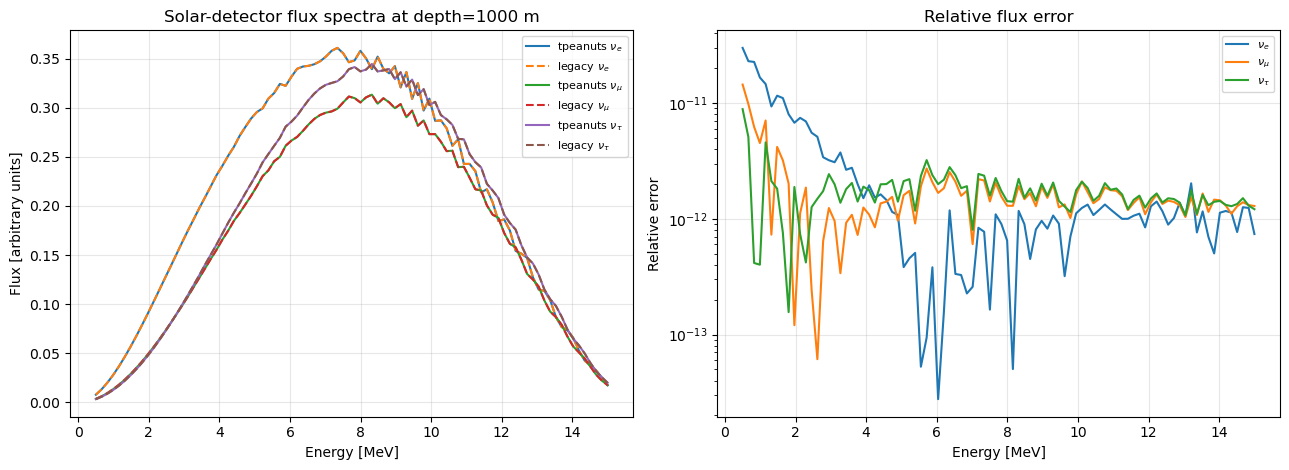

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/solar_detector_flux_spectra.png')

In [15]:
solar_detector_spectrum = solar_source_spectrum(SOLAR_DETECTOR_ENERGY_GRID_MEV)
solar_detector_flux_t = prob_energy_t * solar_detector_spectrum[:, None]
solar_detector_flux_l = prob_energy_l * to_numpy(solar_detector_spectrum)[:, None]

for idx in [0, 20, 45, 70, len(SOLAR_DETECTOR_ENERGY_GRID_MEV) - 1]:
    print_comparison(
        f"Solar-detector flux at E={SOLAR_DETECTOR_ENERGY_GRID_MEV[idx].item():.3f} MeV, depth={SOLAR_DETECTOR_DEPTH_M:.0f} m",
        solar_detector_flux_t[idx],
        solar_detector_flux_l[idx],
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].plot(
        to_numpy(SOLAR_DETECTOR_ENERGY_GRID_MEV),
        to_numpy(solar_detector_flux_t[:, i]),
        label=f"tpeanuts {label}",
    )
    axes[0].plot(
        to_numpy(SOLAR_DETECTOR_ENERGY_GRID_MEV),
        solar_detector_flux_l[:, i],
        "--",
        label=f"legacy {label}",
    )
    axes[1].semilogy(
        to_numpy(SOLAR_DETECTOR_ENERGY_GRID_MEV),
        relative_error(solar_detector_flux_t[:, i], solar_detector_flux_l[:, i]),
        label=label,
    )
axes[0].set_title(f"Solar-detector flux spectra at depth={SOLAR_DETECTOR_DEPTH_M:.0f} m")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Flux [arbitrary units]")
axes[1].set_title("Relative flux error")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Relative error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("solar_detector_flux_spectra.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 7.3 Integrated Probability Comparison

The final comparison integrates detector probabilities over a normalized nadir-angle exposure. This summarizes the complete solar-to-underground-detector precision in one probability vector per energy.


Using tpeanuts pearth method for solar-detector integrated probabilities: analytical

Integrated solar-detector probability at E=1.000 MeV, depth=1000 m
  tpeanuts: [0.5172544414 0.2488878372 0.2338578956]
  legacy  : [0.5172544414 0.2488878372 0.2338578956]
  max abs error: 3.280709e-12
  max rel error: 6.342544e-12

Integrated solar-detector probability at E=3.000 MeV, depth=1000 m
  tpeanuts: [0.4493231514 0.2740161988 0.2766619429]
  legacy  : [0.4493231514 0.2740161988 0.2766619429]
  max abs error: 7.329692e-13
  max rel error: 1.631274e-12

Integrated solar-detector probability at E=5.000 MeV, depth=1000 m
  tpeanuts: [0.3924842558 0.2951013383 0.3124199776]
  legacy  : [0.3924842558 0.2951013383 0.3124199776]
  max abs error: 2.435829e-13
  max rel error: 7.796650e-13

Integrated solar-detector probability at E=8.000 MeV, depth=1000 m
  tpeanuts: [0.3480401858 0.3108123397 0.3411608654]
  legacy  : [0.3480401858 0.3108123397 0.3411608654]
  max abs error: 2.947087e-13
  max rel

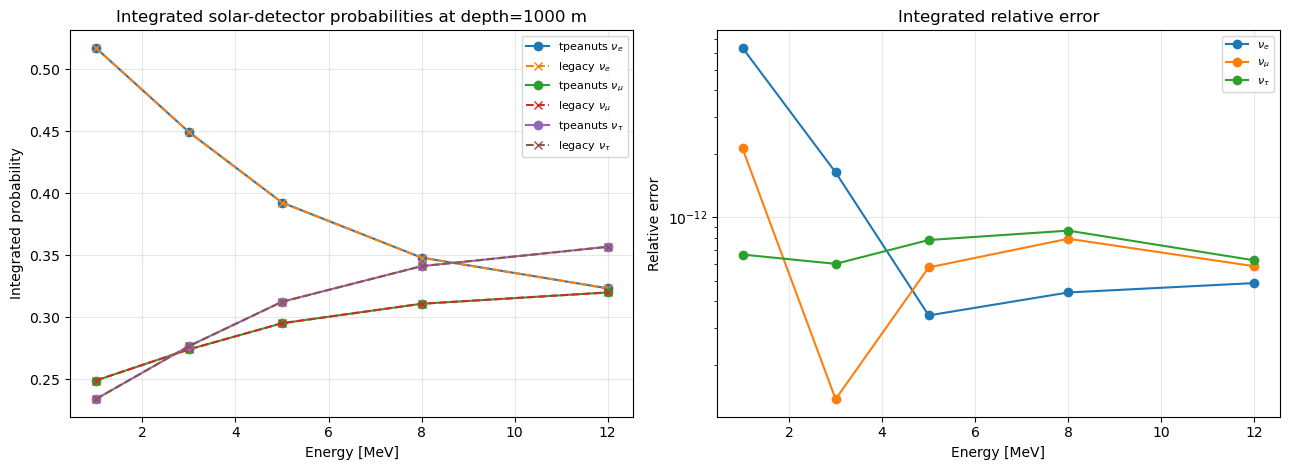

WindowsPath('V:/output/benchmark/0_tpeanuts_vs_peanuts_precision/solar_detector_integrated_probabilities.png')

In [16]:
solar_detector_integrated_E = torch.tensor([1.0, 3.0, 5.0, 8.0, 12.0], dtype=DTYPE, device=DEVICE)
solar_detector_eta_integrated = torch.linspace(0.02, math.pi - 0.02, EXPOSURE_NS, dtype=DTYPE, device=DEVICE)
solar_detector_exposure = torch.ones_like(solar_detector_eta_integrated)
solar_detector_exposure = solar_detector_exposure / torch.trapezoid(
    solar_detector_exposure,
    x=solar_detector_eta_integrated,
).clamp_min(torch.finfo(DTYPE).tiny)

P_sd_eta_t = []
P_sd_eta_l = []
for energy in solar_detector_integrated_E:
    mass_t = solar_detector_mass_weights_t(energy)
    mass_l = solar_detector_mass_weights_l(float(energy))
    probs_t_one_energy = []
    probs_l_one_energy = []
    for eta in solar_detector_eta_integrated:
        probs_t_one_energy.append(
            torch_pearth_probability(
                mass_t,
                earth_density_t,
                pmns,
                energy,
                eta,
                SOLAR_DETECTOR_DEPTH_M,
                massbasis=True,
            )
        )
        probs_l_one_energy.append(
            legacy_pearth(
                mass_l,
                earth_density_l,
                legacy_pmns,
                DM21_EV2,
                DM3L_EV2,
                float(energy),
                float(eta),
                SOLAR_DETECTOR_DEPTH_M,
                mode="analytical",
                massbasis=True,
            )
        )
    P_sd_eta_t.append(torch.stack(probs_t_one_energy, dim=0))
    P_sd_eta_l.append(np.stack(probs_l_one_energy, axis=0))

P_sd_eta_t = torch.stack(P_sd_eta_t, dim=0)
P_sd_eta_l = np.stack(P_sd_eta_l, axis=0)
P_sd_int_t = torch.trapezoid(P_sd_eta_t * solar_detector_exposure[None, :, None], x=solar_detector_eta_integrated, dim=1)
P_sd_int_l = np.trapz(
    P_sd_eta_l * to_numpy(solar_detector_exposure)[None, :, None],
    x=to_numpy(solar_detector_eta_integrated),
    axis=1,
)

print(f"Using tpeanuts pearth method for solar-detector integrated probabilities: {EARTH_METHOD}")
for idx, energy in enumerate(solar_detector_integrated_E):
    print_comparison(
        f"Integrated solar-detector probability at E={energy.item():.3f} MeV, depth={SOLAR_DETECTOR_DEPTH_M:.0f} m",
        P_sd_int_t[idx],
        P_sd_int_l[idx],
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].plot(to_numpy(solar_detector_integrated_E), to_numpy(P_sd_int_t[:, i]), marker="o", label=f"tpeanuts {label}")
    axes[0].plot(to_numpy(solar_detector_integrated_E), P_sd_int_l[:, i], "--", marker="x", label=f"legacy {label}")
    axes[1].semilogy(
        to_numpy(solar_detector_integrated_E),
        relative_error(P_sd_int_t[:, i], P_sd_int_l[:, i]),
        marker="o",
        label=label,
    )
axes[0].set_title(f"Integrated solar-detector probabilities at depth={SOLAR_DETECTOR_DEPTH_M:.0f} m")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Integrated probability")
axes[1].set_title("Integrated relative error")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Relative error")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("solar_detector_integrated_probabilities.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
